# Seasonal Agriculture Performance Analysis

## 1. Introduction

Agricultural performance is influenced by seasonal variations in
environmental conditions, farming practices, resource availability,
crop characteristics and market conditions.

This project analyzes agricultural data across different seasons
to identify meaningful patterns, trends, relationships and variations
in agricultural performance.

The analysis focuses on agricultural yield, production, environmental
conditions, resource utilization, economic performance, water
efficiency and disease/pest risk.

## 2. Problem Statement

Agricultural activities are influenced by seasonal changes in
environmental conditions, farming practices, resource availability
and market conditions.

Raw agricultural data does not clearly explain how agricultural
performance changes across seasons.

Therefore, this project aims to analyze the agricultural dataset
and identify seasonal differences, patterns, relationships and
variations in agricultural performance.

## 3. Objectives

The main objectives of this project are:

- To understand the agricultural dataset.
- To clean and prepare the data for analysis.
- To compare agricultural performance across seasons.
- To analyze crop yield and production across seasons.
- To examine environmental conditions across seasons.
- To study resource usage across seasons.
- To analyze economic performance across seasons.
- To investigate water efficiency.
- To examine disease and pest risk.
- To analyze crop-wise and state-wise seasonal patterns.
- To identify relationships between agricultural variables.
- To perform statistical analysis of seasonal differences.
- To develop evidence-based findings and recommendations.

In [57]:
pip install pandas openpyxl

Note: you may need to restart the kernel to use updated packages.


In [58]:
import pandas as pd


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [60]:
df = pd.read_csv("../data/seasonal_agriculture_performance_dataset.csv")

In [61]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [62]:
df.shape

(4000, 28)

In [63]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [65]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [66]:
df.isnull().sum()

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

In [67]:
df.duplicated().sum()

np.int64(0)

In [68]:
df = df.drop_duplicates()

In [69]:
df.dtypes

Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Profit_INR      

In [70]:
df["Season"].unique()

array(['Kharif', 'Rabi', 'Zaid'], dtype=object)

In [71]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28


In [72]:
print("Column Names:")
for column in df.columns:
    print(column)

Column Names:
Farm_ID
State
District
Crop
Season
Farm_Area_Hectares
Rainfall_mm
Avg_Temperature_C
Humidity_pct
Sunlight_Hours_Day
Soil_pH
Soil_Moisture_pct
Nitrogen_kg_ha
Phosphorus_kg_ha
Potassium_kg_ha
Irrigation_Method
Fertilizer_kg_ha
Pesticide_Litre_ha
Seed_Quality_Score
Yield_Tonnes_Ha
Production_Tonnes
Market_Price_INR_Tonne
Total_Cost_INR
Revenue_INR
Profit_INR
Water_Used_m3
Water_Efficiency_t_per_1000m3
Disease_Pest_Risk_pct


# missing values

In [73]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


In [74]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


## 4. Data Cleaning and Preparation

The dataset was checked for missing values, duplicate records,
incorrect data types and unusual numerical values.

There are missing values in Rainfall_mm, Soil_Moisture_pct and
Yield_Tonnes_Ha. Since these are numerical variables, median
imputation is used to handle the missing values.

No duplicate records were found.

In [75]:
df_clean = df.copy()

df_clean["Rainfall_mm"] = df_clean["Rainfall_mm"].fillna(
    df_clean["Rainfall_mm"].median()
)

df_clean["Soil_Moisture_pct"] = df_clean["Soil_Moisture_pct"].fillna(
    df_clean["Soil_Moisture_pct"].median()
)

df_clean["Yield_Tonnes_Ha"] = df_clean["Yield_Tonnes_Ha"].fillna(
    df_clean["Yield_Tonnes_Ha"].median()
)

In [76]:
print("Missing values after cleaning:")
print(df_clean.isnull().sum().sum())

print("Duplicate rows after cleaning:")
print(df_clean.duplicated().sum())

Missing values after cleaning:
0
Duplicate rows after cleaning:
0


## 5. Categorical Variable Analysis

In [77]:
print("States:")
print(df_clean["State"].value_counts())

print("\nCrops:")
print(df_clean["Crop"].value_counts())

print("\nSeasons:")
print(df_clean["Season"].value_counts())

print("\nIrrigation Methods:")
print(df_clean["Irrigation_Method"].value_counts())

States:
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

Crops:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Seasons:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Irrigation Methods:
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


In [78]:
season_counts = df_clean["Season"].value_counts()

print(season_counts)

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


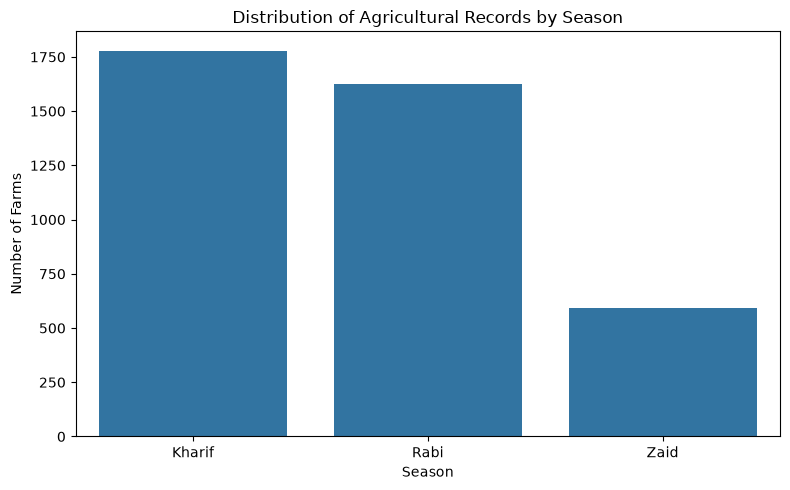

In [79]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df_clean, x="Season")

plt.title("Distribution of Agricultural Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Farms")

plt.tight_layout()
plt.savefig("../visualizations/season_distribution.png")
plt.show()

## 6. Seasonal Agricultural Performance Analysis

The main purpose of this analysis is to understand how agricultural
performance varies across different seasons.

Yield, production, revenue, profit and water efficiency are used
as major performance indicators.

In [80]:
seasonal_performance = df_clean.groupby("Season")[
    [
        "Yield_Tonnes_Ha",
        "Production_Tonnes",
        "Revenue_INR",
        "Profit_INR",
        "Water_Efficiency_t_per_1000m3"
    ]
].mean()

seasonal_performance

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Water_Efficiency_t_per_1000m3
Season,,,,,
Kharif,5.628612,46.311192,710719.055649,178914.647555,5.891834
Rabi,5.039435,41.486712,601526.048556,87689.470191,5.186122
Zaid,4.641313,38.886111,519171.904040,-24804.824916,4.413239


In [81]:
yield_by_season = df_clean.groupby("Season")["Yield_Tonnes_Ha"].mean()

print(yield_by_season)

Season
Kharif    5.628612
Rabi      5.039435
Zaid      4.641313
Name: Yield_Tonnes_Ha, dtype: float64


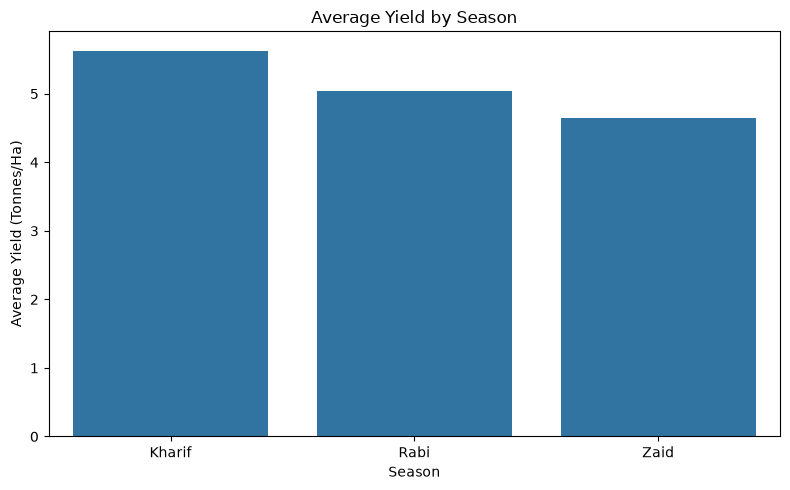

In [82]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=yield_by_season.index,
    y=yield_by_season.values
)

plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.tight_layout()
plt.savefig("../visualizations/yield_by_season.png")
plt.show()

# Production by season

In [83]:
production_by_season = df_clean.groupby("Season")["Production_Tonnes"].mean()

print(production_by_season)

Season
Kharif    46.311192
Rabi      41.486712
Zaid      38.886111
Name: Production_Tonnes, dtype: float64


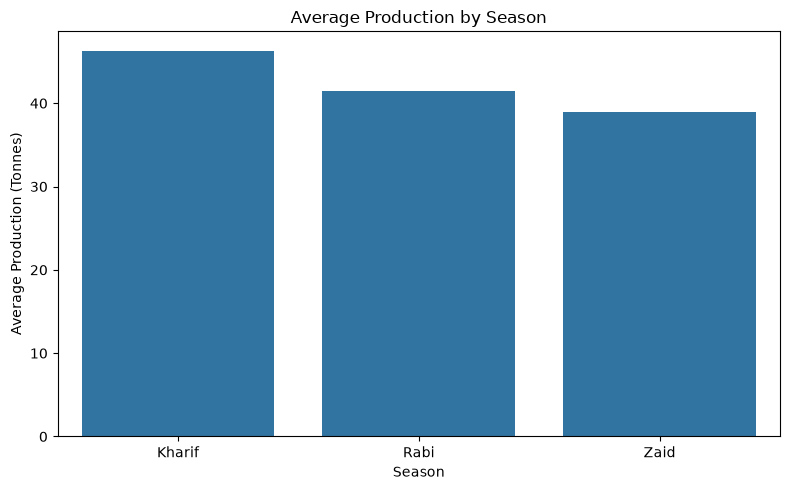

In [84]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=production_by_season.index,
    y=production_by_season.values
)

plt.title("Average Production by Season")
plt.xlabel("Season")
plt.ylabel("Average Production (Tonnes)")

plt.tight_layout()
plt.savefig("../visualizations/production_by_season.png")
plt.show()

# Profit by season

In [85]:
profit_by_season = df_clean.groupby("Season")["Profit_INR"].mean()

print(profit_by_season)

Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64


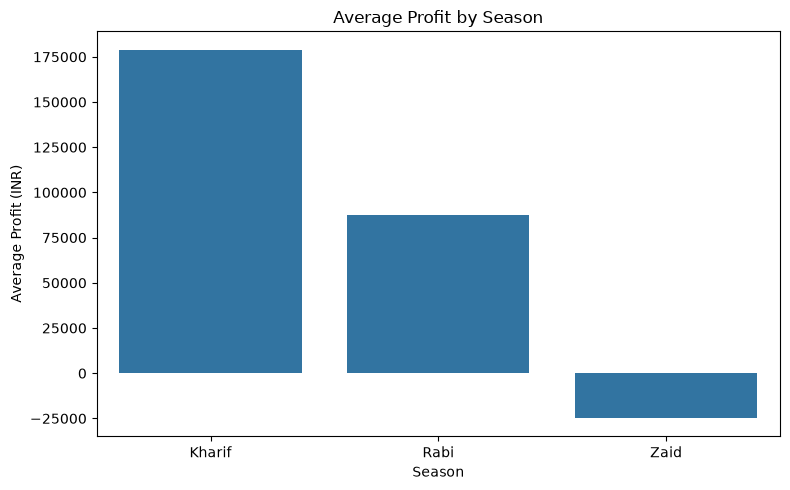

In [86]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=profit_by_season.index,
    y=profit_by_season.values
)

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")

plt.tight_layout()
plt.savefig("../visualizations/profit_by_season.png")
plt.show()

# Revenue by season

In [87]:
revenue_by_season = df_clean.groupby("Season")["Revenue_INR"].mean()

print(revenue_by_season)

Season
Kharif    710719.055649
Rabi      601526.048556
Zaid      519171.904040
Name: Revenue_INR, dtype: float64


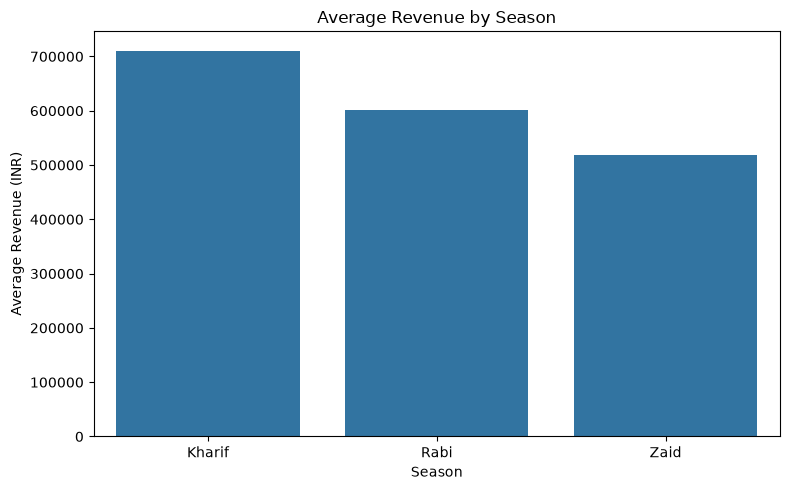

In [88]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=revenue_by_season.index,
    y=revenue_by_season.values
)

plt.title("Average Revenue by Season")
plt.xlabel("Season")
plt.ylabel("Average Revenue (INR)")

plt.tight_layout()
plt.savefig("../visualizations/revenue_by_season.png")
plt.show()

# yield distribution

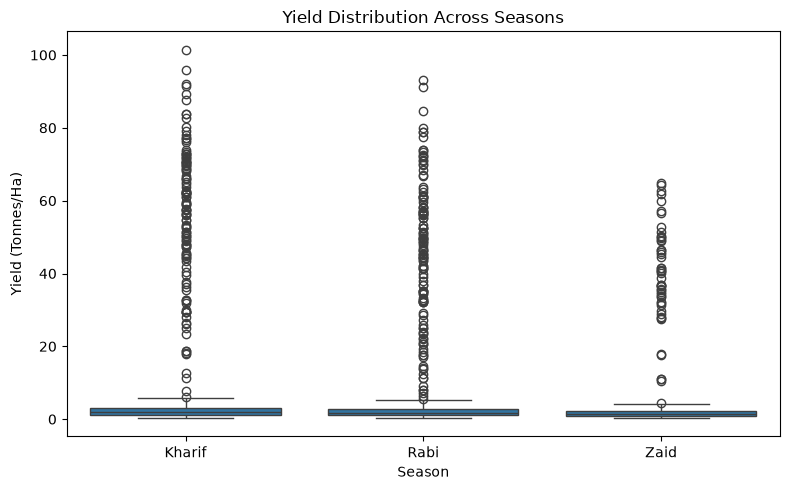

In [89]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Season",
    y="Yield_Tonnes_Ha"
)

plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.savefig("../visualizations/yield_distribution_season.png")
plt.show()

## 7. Environmental Conditions Across Seasons

Environmental factors such as rainfall, temperature, humidity,
sunlight and soil moisture can vary across seasons.

This section compares these environmental conditions across
different seasons.

In [90]:
environmental = df_clean.groupby("Season")[
    [
        "Rainfall_mm",
        "Avg_Temperature_C",
        "Humidity_pct",
        "Sunlight_Hours_Day",
        "Soil_pH",
        "Soil_Moisture_pct"
    ]
].mean()

environmental

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct
Season,,,,,,
Kharif,849.199663,28.454019,71.812591,6.793367,6.727993,31.149859
Rabi,437.615366,23.489183,57.893178,7.589797,6.673749,24.069392
Zaid,304.654714,31.042088,52.012121,8.178788,6.694865,19.279630


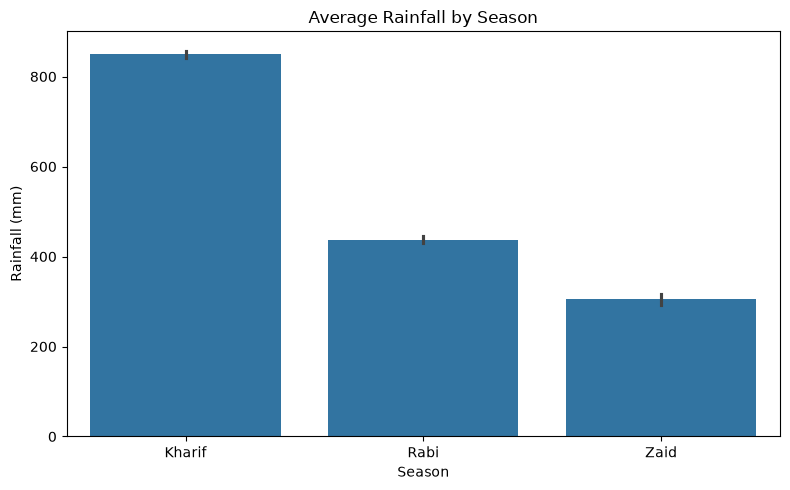

In [91]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x="Season",
    y="Rainfall_mm"
)

plt.title("Average Rainfall by Season")
plt.xlabel("Season")
plt.ylabel("Rainfall (mm)")

plt.tight_layout()
plt.savefig("../visualizations/rainfall_by_season.png")
plt.show()

# Temperature

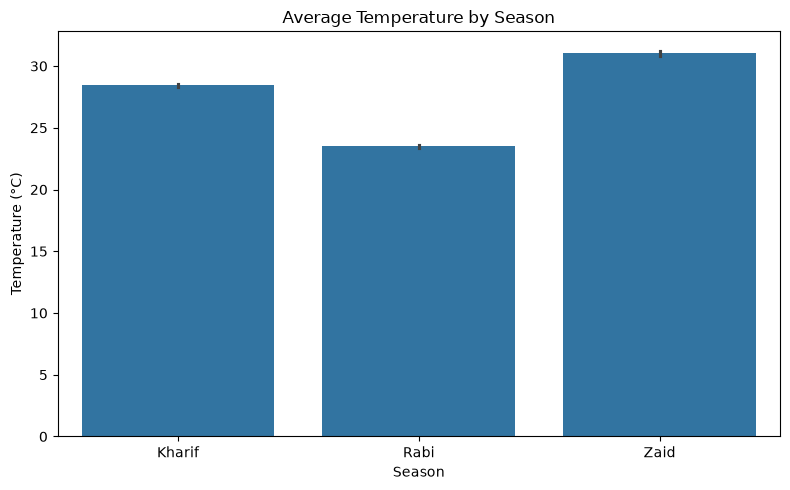

In [92]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x="Season",
    y="Avg_Temperature_C"
)

plt.title("Average Temperature by Season")
plt.xlabel("Season")
plt.ylabel("Temperature (°C)")

plt.tight_layout()
plt.savefig("../visualizations/temperature_by_season.png")
plt.show()

# Soil moisture

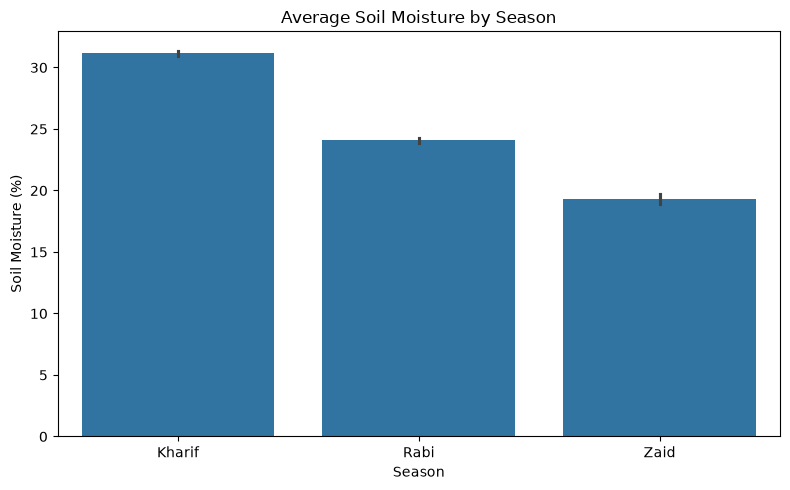

In [93]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x="Season",
    y="Soil_Moisture_pct"
)

plt.title("Average Soil Moisture by Season")
plt.xlabel("Season")
plt.ylabel("Soil Moisture (%)")

plt.tight_layout()
plt.savefig("../visualizations/soil_moisture_by_season.png")
plt.show()

## 8. Resource Usage Across Seasons

This section examines how agricultural resources such as fertilizer,
pesticides, nutrients and water are utilized across different seasons.

In [94]:
resource_usage = df_clean.groupby("Season")[
    [
        "Nitrogen_kg_ha",
        "Phosphorus_kg_ha",
        "Potassium_kg_ha",
        "Fertilizer_kg_ha",
        "Pesticide_Litre_ha",
        "Water_Used_m3"
    ]
].mean()

resource_usage

,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3
Season,,,,,,
Kharif,120.020124,58.096515,105.303485,187.077965,5.079747,6102.201237
Rabi,120.402827,57.311002,103.926060,185.407068,5.024690,5846.987093
Zaid,120.525421,58.129125,105.416835,184.638047,5.171212,6419.893939


In [95]:
water_by_season = df_clean.groupby("Season")["Water_Used_m3"].mean()

print(water_by_season)

Season
Kharif    6102.201237
Rabi      5846.987093
Zaid      6419.893939
Name: Water_Used_m3, dtype: float64


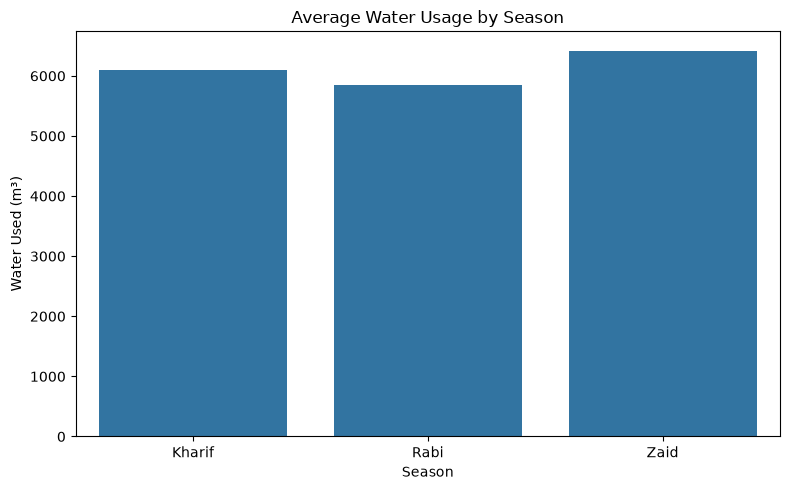

In [96]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=water_by_season.index,
    y=water_by_season.values
)

plt.title("Average Water Usage by Season")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")

plt.tight_layout()
plt.savefig("../visualizations/water_usage_by_season.png")
plt.show()

# WATER EFFICIENCY

In [97]:
efficiency_by_season = df_clean.groupby("Season")[
    "Water_Efficiency_t_per_1000m3"
].mean()

print(efficiency_by_season)

Season
Kharif    5.891834
Rabi      5.186122
Zaid      4.413239
Name: Water_Efficiency_t_per_1000m3, dtype: float64


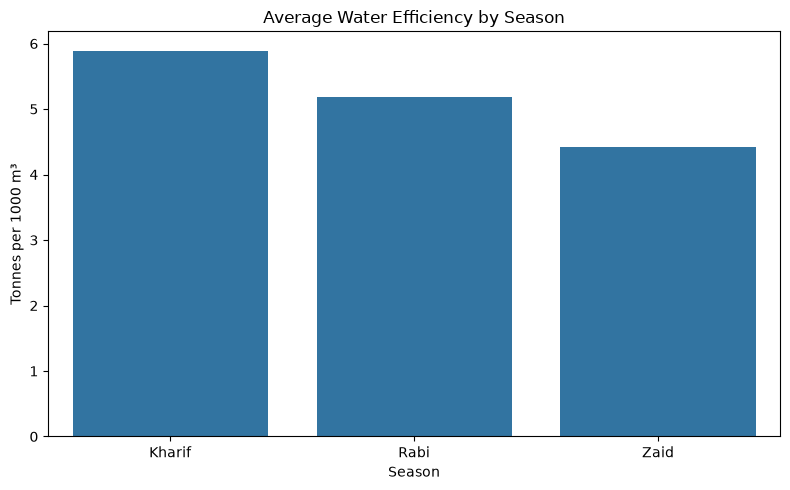

In [98]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=efficiency_by_season.index,
    y=efficiency_by_season.values
)

plt.title("Average Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Tonnes per 1000 m³")

plt.tight_layout()
plt.savefig("../visualizations/water_efficiency_by_season.png")
plt.show()

## 9. Economic Performance Across Seasons

In [99]:
economic = df_clean.groupby("Season")[
    [
        "Market_Price_INR_Tonne",
        "Total_Cost_INR",
        "Revenue_INR",
        "Profit_INR"
    ]
].mean()

economic

,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,,
Kharif,44850.906127,531804.408094,710719.055649,178914.647555
Rabi,44747.974800,513836.578365,601526.048556,87689.470191
Zaid,44212.033670,543976.728956,519171.904040,-24804.824916


## 10. Crop-wise Seasonal Analysis

In [100]:
crop_season_yield = pd.pivot_table(
    df_clean,
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

crop_season_yield

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.731459,1.465031,1.195312
Cotton,1.374512,1.198358,0.960217
Groundnut,1.484974,1.233164,1.037778
Maize,2.966410,2.603648,2.290952
Pulses,1.036063,0.875962,0.669677
Rice,2.698376,2.322847,1.900490
Sugarcane,53.459120,43.286124,38.423922
Wheat,2.253664,2.057468,1.748588


# HEATMAP:

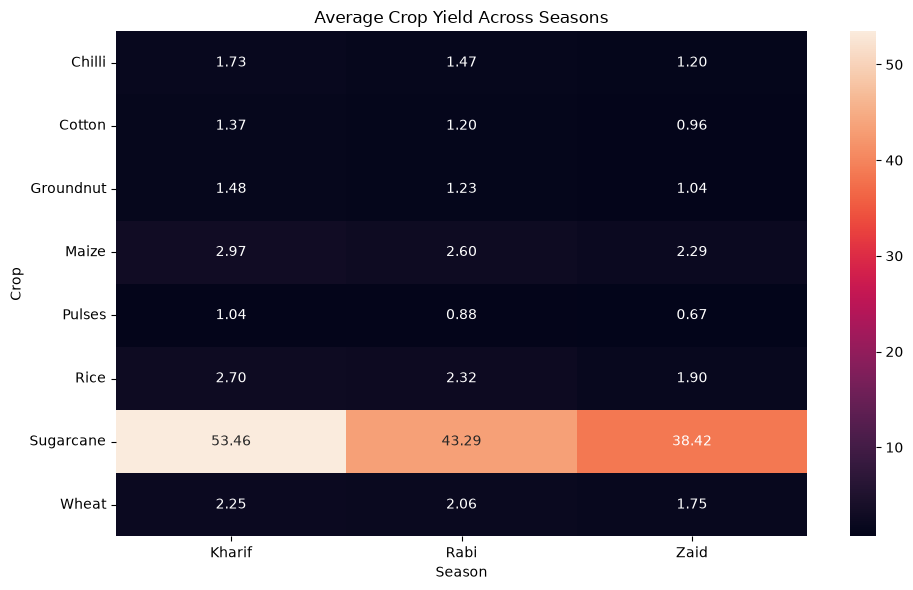

In [101]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt=".2f"
)

plt.title("Average Crop Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Crop")

plt.tight_layout()
plt.savefig("../visualizations/crop_season_yield_heatmap.png")
plt.show()

## 11. State-wise Seasonal Analysis

In [102]:
state_season_yield = pd.pivot_table(
    df_clean,
    values="Yield_Tonnes_Ha",
    index="State",
    columns="Season",
    aggfunc="mean"
)

state_season_yield

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.676958,3.470931,4.448000
Gujarat,6.338416,5.441700,4.066716
Karnataka,6.455024,4.567864,6.623243
Madhya Pradesh,5.985265,3.760385,5.478889
Maharashtra,5.430315,5.501927,2.277778
Punjab,4.100633,8.609355,5.909610
Tamil Nadu,5.520534,4.501394,4.097746
Telangana,5.552436,4.784569,4.248471


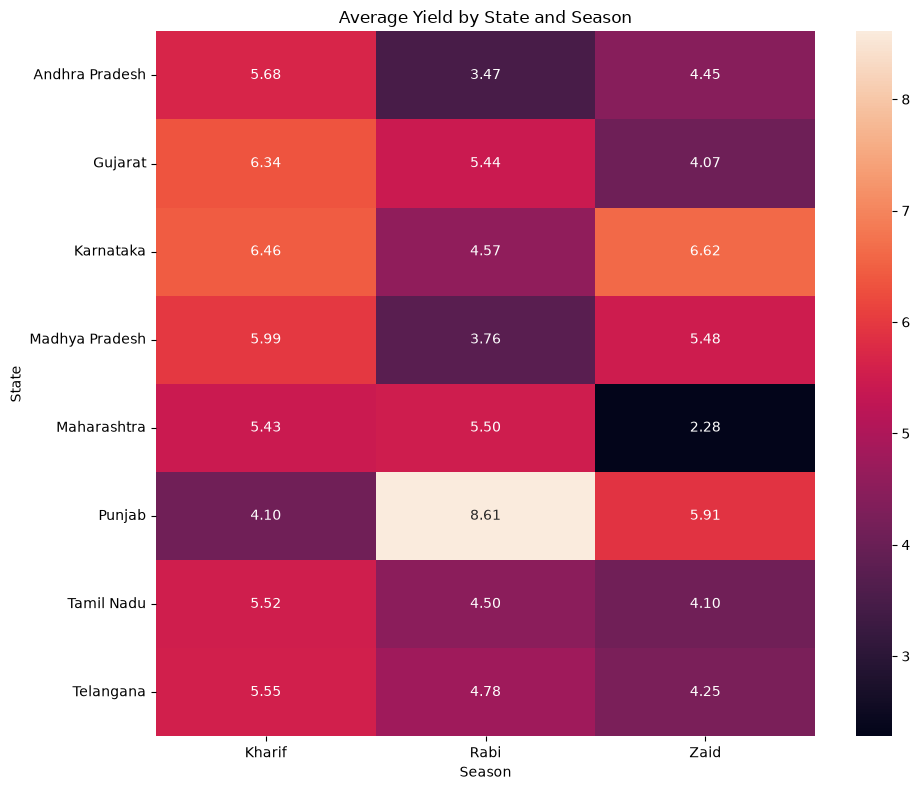

In [103]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    state_season_yield,
    annot=True,
    fmt=".2f"
)

plt.title("Average Yield by State and Season")
plt.xlabel("Season")
plt.ylabel("State")

plt.tight_layout()
plt.savefig("../visualizations/state_season_yield_heatmap.png")
plt.show()

## 12. Disease and Pest Risk Analysis

In [104]:
risk_by_season = df_clean.groupby("Season")[
    "Disease_Pest_Risk_pct"
].mean()

print(risk_by_season)

Season
Kharif    54.467903
Rabi      40.482114
Zaid      38.216667
Name: Disease_Pest_Risk_pct, dtype: float64


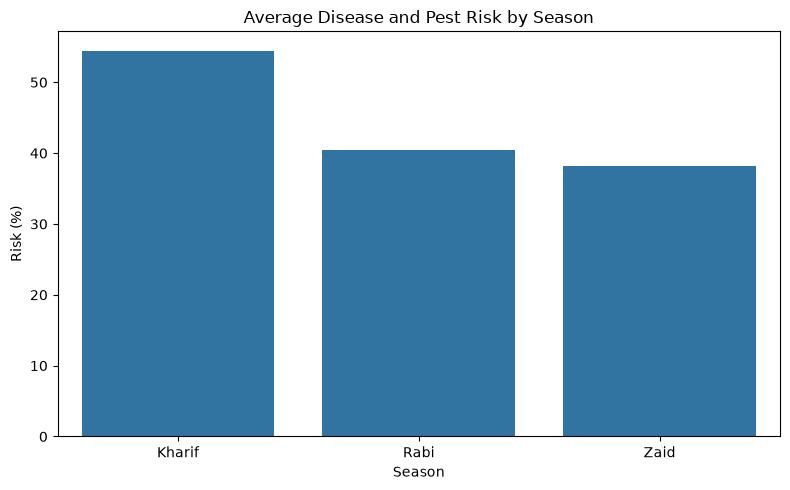

In [105]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=risk_by_season.index,
    y=risk_by_season.values
)

plt.title("Average Disease and Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Risk (%)")

plt.tight_layout()
plt.savefig("../visualizations/disease_pest_risk_by_season.png")
plt.show()

## 13. Correlation Analysis

Correlation analysis is used to examine the strength and direction
of relationships between numerical agricultural variables.

Correlation does not imply causation.

In [106]:
numeric_columns = df_clean.select_dtypes(
    include=["int64", "float64"]
)

correlation_matrix = numeric_columns.corr()

correlation_matrix

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Farm_Area_Hectares,1.000000,0.007256,0.036870,0.000471,0.001821,0.009857,0.004033,0.013658,-0.006625,0.000195,...,0.015236,0.030203,0.197842,-0.021571,0.962211,0.543364,0.115241,0.576015,0.028930,0.025963
Rainfall_mm,0.007256,1.000000,0.198492,0.521069,-0.362779,0.016657,0.508941,0.007460,0.020940,0.031373,...,-0.018581,0.030951,0.024447,0.000639,0.013041,0.098146,0.107648,0.002240,0.058102,0.621762
Avg_Temperature_C,0.036870,0.198492,1.000000,0.138136,-0.033863,0.029988,0.084001,0.018707,0.008508,0.022993,...,-0.031943,0.009996,0.007346,0.002951,0.041030,0.026703,0.009043,0.022995,0.006534,0.245613
Humidity_pct,0.000471,0.521069,0.138136,1.000000,-0.297298,0.028447,0.446470,0.001198,-0.005963,-0.003070,...,-0.045598,0.012297,0.003614,0.000262,0.006023,0.057358,0.063775,-0.002086,0.026169,0.545093
Sunlight_Hours_Day,0.001821,-0.362779,-0.033863,-0.297298,1.000000,-0.017806,-0.302846,0.009920,0.001544,-0.014407,...,0.021257,-0.015341,-0.023504,-0.000696,-0.000655,-0.047216,-0.054822,-0.005717,-0.021386,-0.253251
Soil_pH,0.009857,0.016657,0.029988,0.028447,-0.017806,1.000000,0.031183,0.006286,0.016620,-0.019407,...,-0.004181,-0.020672,-0.012512,0.022226,0.005302,-0.008798,-0.013145,-0.022859,-0.010087,0.031141
Soil_Moisture_pct,0.004033,0.508941,0.084001,0.446470,-0.302846,0.031183,1.000000,0.008884,0.013406,0.007796,...,-0.019556,0.010999,0.004787,0.016914,0.002741,0.079380,0.091281,0.003183,0.027776,0.375547
Nitrogen_kg_ha,0.013658,0.007460,0.018707,0.001198,0.009920,0.006286,0.008884,1.000000,0.010199,0.010490,...,0.014896,0.053149,0.048182,-0.022595,0.011900,0.078252,0.085016,0.022127,0.054896,-0.011503
Phosphorus_kg_ha,-0.006625,0.020940,0.008508,-0.005963,0.001544,0.016620,0.013406,0.010199,1.000000,0.002847,...,-0.007575,0.047941,0.034957,-0.005174,-0.016508,0.034940,0.049747,-0.000752,0.057129,0.032061
Potassium_kg_ha,0.000195,0.031373,0.022993,-0.003070,-0.014407,-0.019407,0.007796,0.010490,0.002847,1.000000,...,0.006862,0.003382,0.004472,0.007572,0.003431,0.028278,0.031192,0.001667,0.006575,0.013403


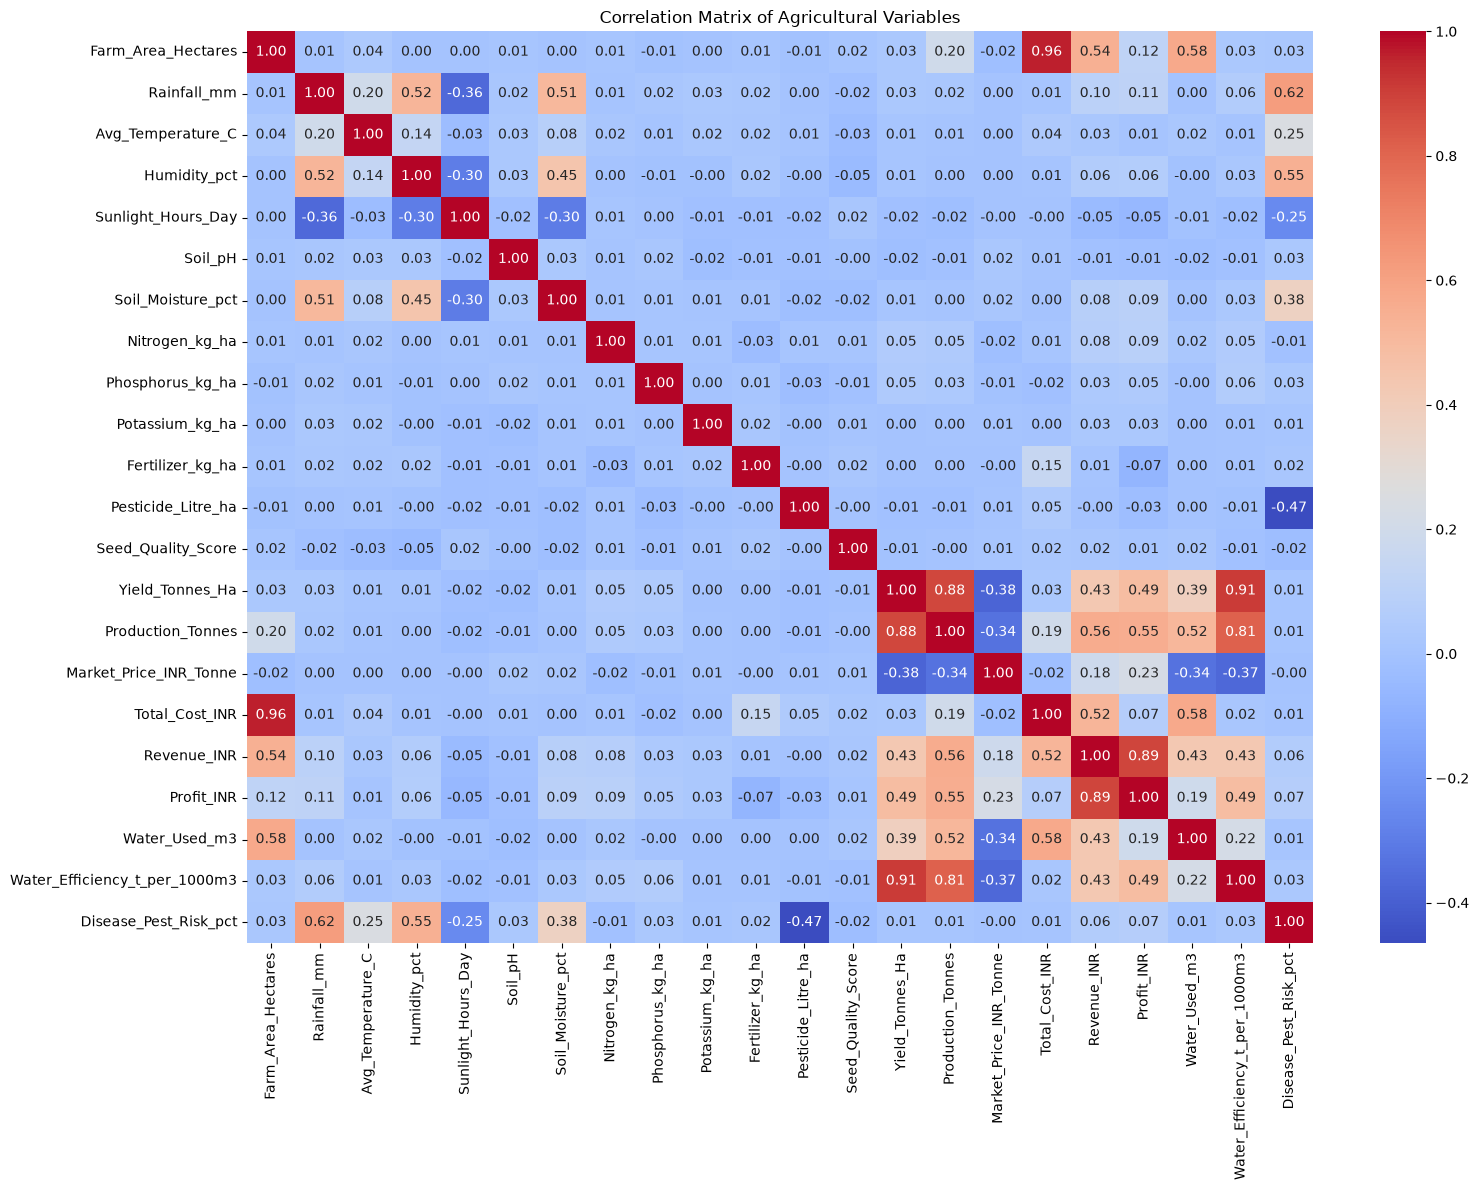

In [108]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Agricultural Variables")

plt.tight_layout()
plt.savefig("../visualizations/correlation_heatmap.png")
plt.show()

## Environmental factors vs yield

# Rainfall vs Yield

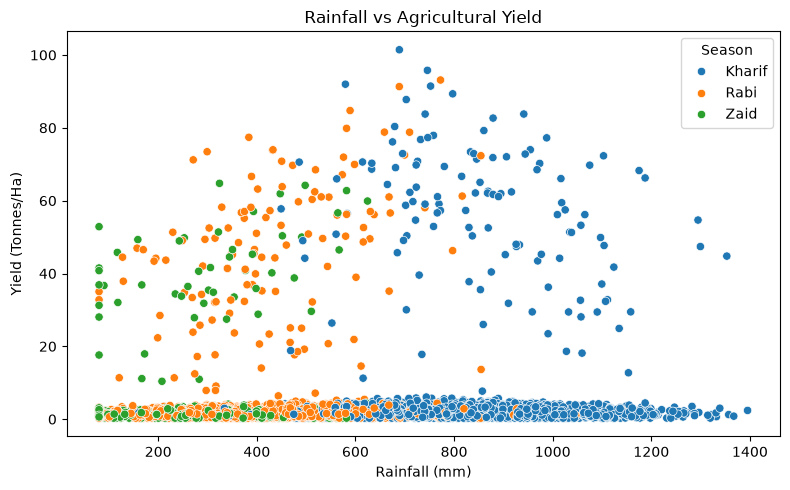

In [109]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Rainfall vs Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.savefig("../visualizations/rainfall_vs_yield.png")
plt.show()

# Temperature vs Yield

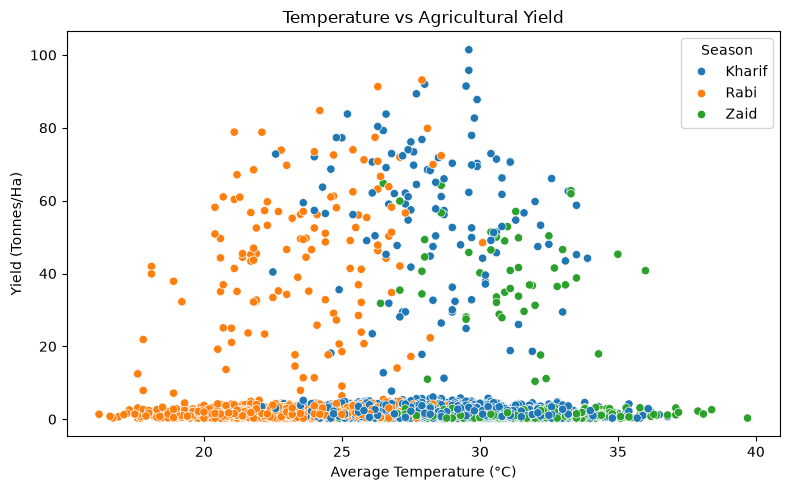

In [110]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x="Avg_Temperature_C",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Temperature vs Agricultural Yield")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.savefig("../visualizations/temperature_vs_yield.png")
plt.show()

## 14. Statistical Analysis

A statistical test is performed to determine whether agricultural
yield differs significantly across seasons.

The significance level is set at 0.05.

In [111]:
season_groups = [
    group["Yield_Tonnes_Ha"].dropna()
    for name, group in df_clean.groupby("Season")
]

anova_result = stats.f_oneway(*season_groups)

print("F-statistic:", anova_result.statistic)
print("p-value:", anova_result.pvalue)

F-statistic: 1.5438804542488311
p-value: 0.21367813841845013


In [112]:
alpha = 0.05

if anova_result.pvalue < alpha:
    print("The difference in yield across seasons is statistically significant.")
else:
    print("The difference in yield across seasons is not statistically significant.")

The difference in yield across seasons is not statistically significant.


## 15. Outlier Analysis

Box plots are used to identify potentially unusual observations
in important agricultural performance variables.

Potential outliers are not automatically removed because they may
represent genuine agricultural conditions.

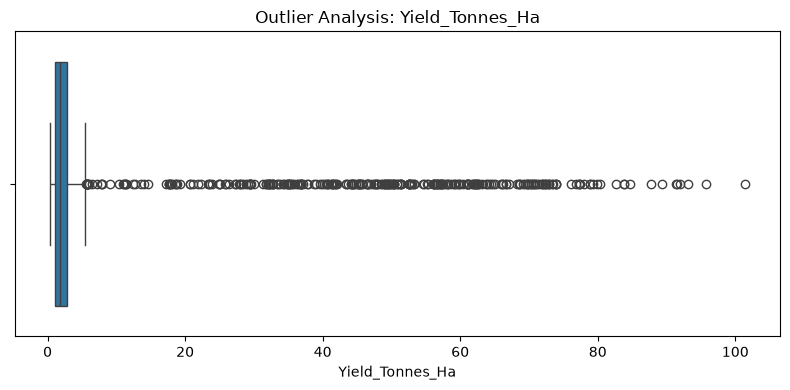

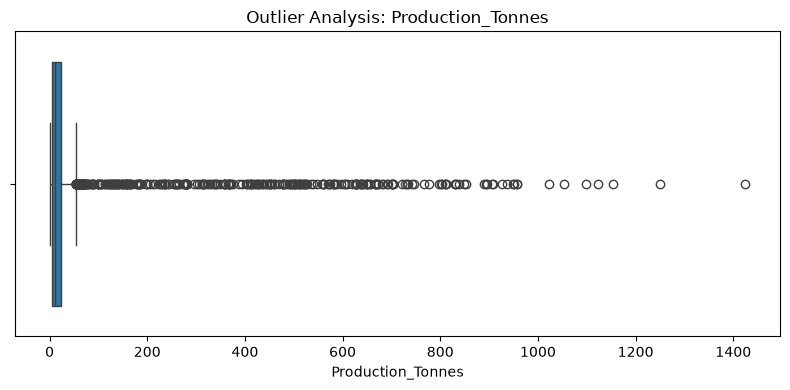

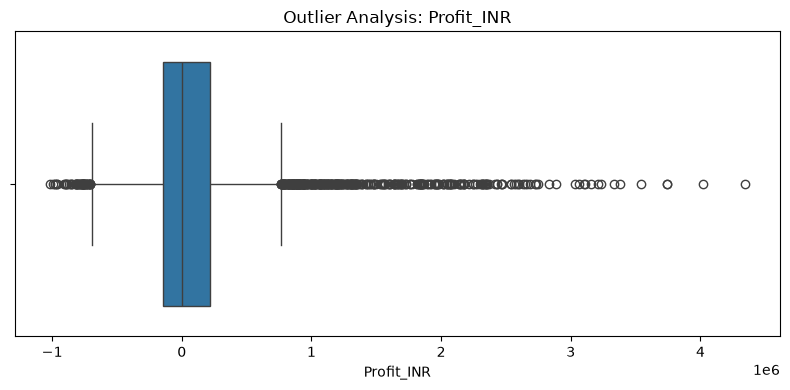

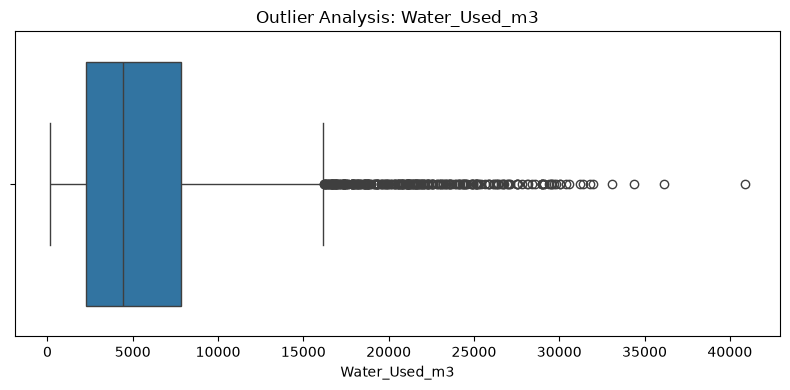

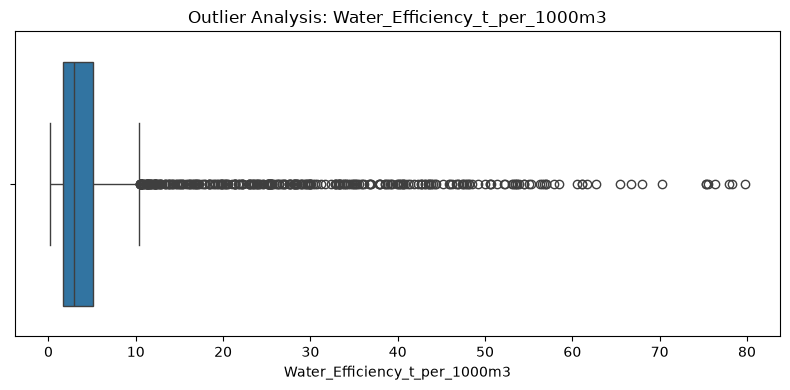

In [113]:
important_variables = [
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3"
]

for column in important_variables:
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(x=df_clean[column])
    
    plt.title(f"Outlier Analysis: {column}")
    plt.xlabel(column)
    
    plt.tight_layout()
    plt.show()

# which season is best.

In [115]:
best_yield_season = yield_by_season.idxmax()
worst_yield_season = yield_by_season.idxmin()

print("Highest average yield:", best_yield_season)
print("Lowest average yield:", worst_yield_season)

Highest average yield: Kharif
Lowest average yield: Zaid


# PROFIT:

In [116]:
best_profit_season = profit_by_season.idxmax()
worst_profit_season = profit_by_season.idxmin()

print("Highest average profit:", best_profit_season)
print("Lowest average profit:", worst_profit_season)

Highest average profit: Kharif
Lowest average profit: Zaid


# Water efficiency:

In [117]:
best_water_efficiency_season = efficiency_by_season.idxmax()

print(
    "Highest water efficiency season:",
    best_water_efficiency_season
)

Highest water efficiency season: Kharif


# RISK:

In [118]:
highest_risk_season = risk_by_season.idxmax()
lowest_risk_season = risk_by_season.idxmin()

print("Highest disease/pest risk:", highest_risk_season)
print("Lowest disease/pest risk:", lowest_risk_season)

Highest disease/pest risk: Kharif
Lowest disease/pest risk: Zaid


## 17. Recommendations

Based on the findings of the analysis:

- Seasonal planning should consider differences in agricultural
  performance across seasons.

- Water resources should be allocated according to seasonal
  water requirements and observed water efficiency.

- Crop selection can consider the seasonal performance patterns
  identified in the dataset.

- Resource usage such as fertilizer and pesticides should be
  monitored across seasons.

- Seasons or regions with higher disease and pest risk may require
  closer monitoring.

- Regions showing relatively lower performance can be investigated
  further to understand the factors affecting productivity.

- Environmental conditions should be considered while planning
  agricultural activities.

## 18. Conclusion

This project analyzed agricultural data across different seasons
to identify patterns and variations in agricultural performance.

The analysis examined yield, production, environmental conditions,
resource usage, economic performance, water efficiency and
disease/pest risk.

Season-wise, crop-wise and state-wise comparisons were performed
using statistical summaries and visualizations. Correlation analysis
was also used to investigate relationships between agricultural
variables, while statistical testing was used to examine seasonal
differences in yield.

Overall, the project demonstrates how data analytics can be used to
understand seasonal agricultural patterns and support evidence-based
agricultural planning.